## Περιγραφή προβλήματος

Το σύνολο δεδομένων Iris είναι ένα κλασικό σύνολο δεδομένων στην επιστήμη των δεδομένων και τη μηχανική μάθηση, το οποίο περιέχει μετρήσεις από τρία διαφορετικά είδη λουλουδιών ίριδας: setosa, versicolor και virginica. Για κάθε λουλούδι, καταγράφονται τέσσερα χαρακτηριστικά (μεταβλητές):

1.  **μήκος σέπαλου (sepal length)**
2.  **πλάτος σέπαλου (sepal width)**
3.  **μήκος πέταλου (petal length)**
4.  **πλάτος πέταλου (petal width)**

Το πρόβλημα ταξινόμησης έγκειται στην ανάπτυξη ενός μοντέλου που μπορεί να προβλέψει σωστά το είδος του λουλουδιού ίριδας (setosa, versicolor ή virginica) με βάση αυτά τα τέσσερα χαρακτηριστικά. Αυτό είναι ένα παράδειγμα προβλήματος πολυκατηγορικής ταξινόμησης, όπου ο στόχος είναι να αντιστοιχιστεί κάθε δείγμα σε μία από τις τρεις διακριτές κλάσεις (είδη).

Σε αυτή την εργασία, χρησιμοποιούμε τον αλγόριθμο ταξινόμησης k-Nearest Neighbors (kNN) για να αντιμετωπίσουμε αυτό το πρόβλημα. Εκπαιδεύουμε το μοντέλο στα δεδομένα εκπαίδευσης και στη συνέχεια αξιολογούμε την ικανότητά του να ταξινομεί νέα, αόρατα δείγματα του συνόλου δεδομένων δοκιμής. Η αξιολόγηση γίνεται με τη χρήση μετρικών όπως η ακρίβεια (accuracy) και η ανάκληση (recall), καθώς και με την οπτικοποίηση του πίνακα σύγχυσης (confusion matrix) για να κατανοήσουμε καλύτερα την απόδοση του μοντέλου σε κάθε κλάση.

## Φόρτωση δεδομένων (data loading)

### Subtask:
Load the Iris dataset using scikit-learn.


In [ ]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
# Create a pandas DataFrame from the iris data
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
# Add the target column to the DataFrame
df['target'] = iris.target
print(df.head()) # Print the first few rows to verify
print(f"\nTotal number of instances: {df.shape[0]}")
print(iris.target_names)

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Total number of instances: 150
['setosa' 'versicolor' 'virginica']


## Διαχωρισμός δεδομένων (data splitting)
Split the dataset into training and testing sets.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.3)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (105, 4)
Shape of X_test: (45, 4)
Shape of y_train: (105,)
Shape of y_test: (45,)


## Εκπαίδευση μοντέλου (model training)

Train a K-Nearest Neighbors classifier on the training data.


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Changing n_neighbors to potentially introduce some misclassifications
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

## Προβλέψεις
Make predictions on the testing data using the trained model.


In [ ]:
y_pred = knn.predict(X_test)
print(y_pred)

[0 2 0 2 0 1 1 1 1 2 2 2 1 1 1 2 1 1 2 0 2 1 1 2 1 2 2 2 0 1 1 0 0 1 1 0 0
 0 1 2 0 1 0 0 2]


In [ ]:
import pandas as pd

comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
comparison_df['Correct'] = comparison_df['Actual'] == comparison_df['Predicted']
print(comparison_df)

    Actual  Predicted  Correct
0        0          0     True
1        1          2    False
2        0          0     True
3        2          2     True
4        0          0     True
5        1          1     True
6        1          1     True
7        1          1     True
8        1          1     True
9        2          2     True
10       2          2     True
11       2          2     True
12       1          1     True
13       1          1     True
14       1          1     True
15       2          2     True
16       2          1    False
17       1          1     True
18       2          2     True
19       0          0     True
20       2          2     True
21       1          1     True
22       1          1     True
23       2          2     True
24       1          1     True
25       2          2     True
26       2          2     True
27       2          2     True
28       0          0     True
29       1          1     True
30       1          1     True
31      

## Αξιολόγηση μοντέλου (model evaluation)
Compute the accuracy and recall of the model.


In [ ]:
from sklearn.metrics import accuracy_score, recall_score

accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred, average='weighted')

print(f"Ακρίβεια μοντέλου (Accuracy): {accuracy:.4f}")
print(f"Ανάκληση μοντέλου (Recall): {recall:.4f}")

Ακρίβεια μοντέλου (Accuracy): 0.9556
Ανάκληση μοντέλου (Recall): 0.9556


## Πίνακας σύγχυσης (confusion matrix)
Visualize the confusion matrix.


In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

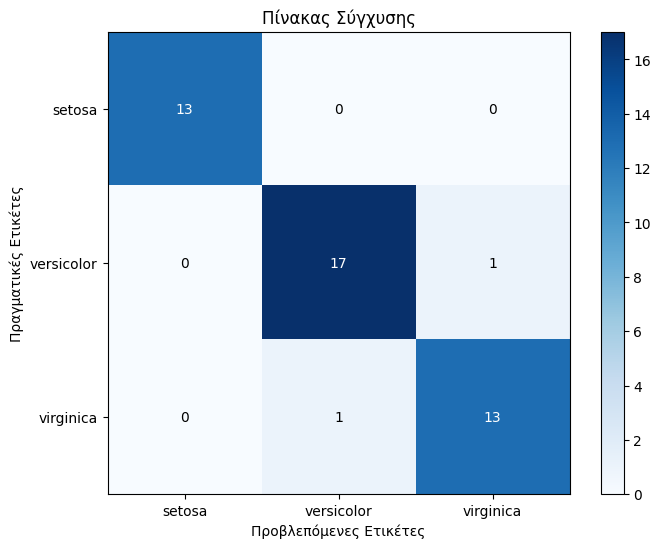

In [ ]:
import numpy as np

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Πίνακας Σύγχυσης")
plt.colorbar()
tick_marks = np.arange(len(iris.target_names))
plt.xticks(tick_marks, iris.target_names)
plt.yticks(tick_marks, iris.target_names)

fmt = 'd'
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], fmt),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel("Πραγματικές Ετικέτες")
plt.xlabel("Προβλεπόμενες Ετικέτες")
plt.show()